In [2]:

import os
import sys


In [3]:
sys.path.append('src')
from data.dataloader import * 
from data.tickers import TICKERS
from models.run_optuna import *

245


In [5]:
FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]


loader = Dataloader(data_root="src/data/moex_candles")
dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=60,
    step_size=5,
    feature_cols=FEATURE_COLS,
    interval="daily",
)
print(f"  Loaded {len(dataset)} / {len(TICKERS)} tickers")
X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)
print(f"  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


  Loaded 236 / 245 tickers
  X_train: (114378, 60, 18)  X_val: (19700, 60, 18)  X_test: (14310, 60, 18)


In [6]:
import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
!pip install ts2vec

In [8]:
from embeddings.TS2Vec_embedder import TS2VecEmbedder
from clustering.kmeans import KMeansClusterer

In [9]:
num_features = X_train.shape[2]

# Train TS2Vec embedder (contrastive learning on subsequences)
ts2vec_emb = TS2VecEmbedder(
    input_size=num_features, hidden_size=64, output_size=320, device = 'cuda', depth=10
)
train_raw_emb = ts2vec_emb.fit_transform(X_train, n_epochs=1, verbose=True)
val_raw_emb   = ts2vec_emb.transform(X_val)
test_raw_emb  = ts2vec_emb.transform(X_test)
print(f"Raw TS2Vec embeddings — train: {train_raw_emb.shape}, "
      f"val: {val_raw_emb.shape}, test: {test_raw_emb.shape}")

Epoch #0: loss=0.30396932235407675
Raw TS2Vec embeddings — train: (114378, 320), val: (19700, 320), test: (14310, 320)


In [10]:
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from embeddings.TS2Vec_embedder import TS2VecEmbedder
from clustering.kmeans import KMeansClusterer
from clustering.hdbscan import HDBSCANClusterer
from clustering.cluster_analysis import (
    elbow_scores, plot_elbow, plot_clusters_2d, cluster_stats,
)
from clustering.umap_reducer import UMAPProjector
from evaluation.metrics import regression_metrics, directional_accuracy
from evaluation.compare import ComparisonTable
from models import (
    LSTMModel, GRUModel, CNNModel, TransformerModel,
    LightGBMModel, ArimaModel,
)


# UMAP: fit on train, transform all
umap_proj = UMAPProjector(n_components=15, random_state=42)
train_embeddings = umap_proj.fit_transform(train_raw_emb)
val_embeddings   = umap_proj.transform(val_raw_emb)
test_embeddings  = umap_proj.transform(test_raw_emb)

print(f"UMAP embeddings — train: {train_embeddings.shape}, "
      f"val: {val_embeddings.shape}, test: {test_embeddings.shape}")

UMAP embeddings — train: (114378, 15), val: (19700, 15), test: (14310, 15)


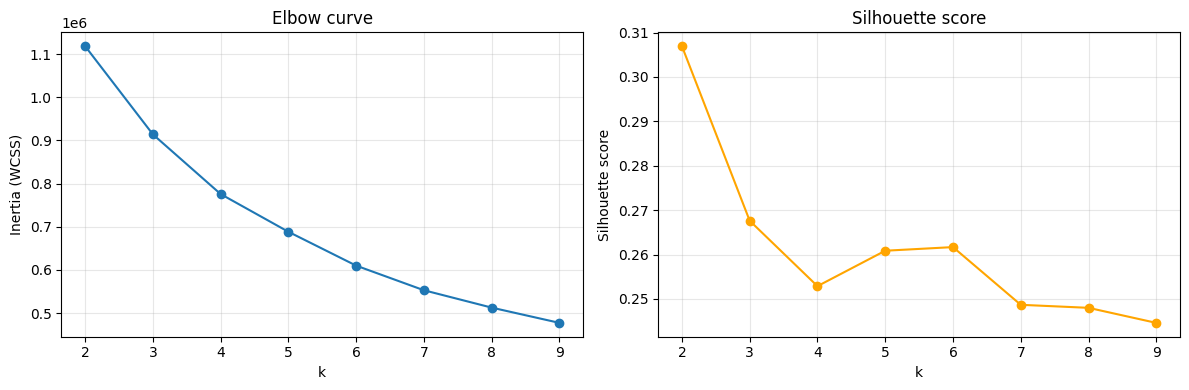

Best k by silhouette: 2  (silhouette=0.307)


In [11]:
# ── Cell 4: Elbow analysis — choose k for KMeans ─────────────────────────────
scores = plot_elbow(train_embeddings, k_range=range(2, 10),
                    random_state=42)

best_idx = int(np.argmax(scores["silhouette"]))
BEST_K = scores["k"][best_idx]
print(f"Best k by silhouette: {BEST_K}  "
      f"(silhouette={scores['silhouette'][best_idx]:.3f})")

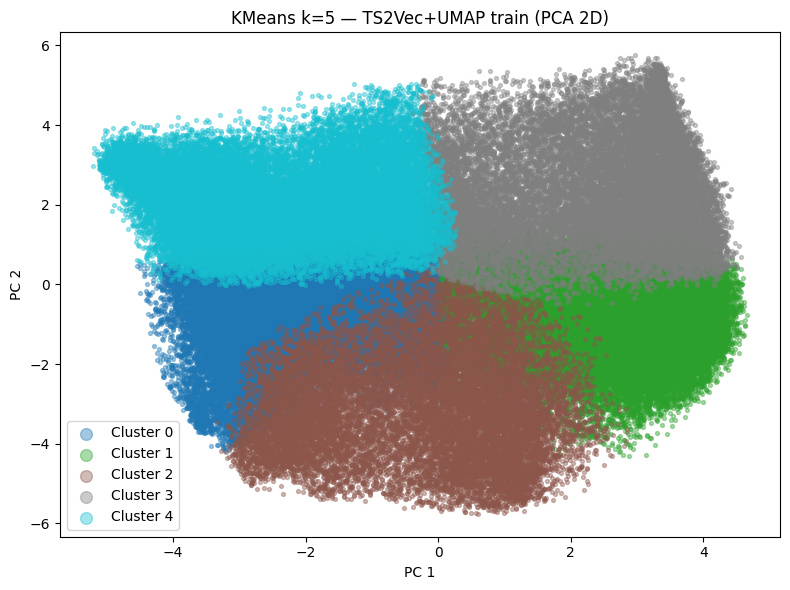

         count  return_mean  return_std  return_median        pct
cluster                                                          
0        24800    -0.000588    0.043011            0.0  21.682491
1        26604     0.001116    0.034376            0.0  23.259718
2        17191     0.000296    0.034573            0.0  15.029988
3        21122     0.000193    0.046154            0.0  18.466838
4        24661     0.000126    0.040633            0.0  21.560965


In [31]:
# ── Cell 5: KMeans clustering ────────────────────────────────────────────────
kmeans = KMeansClusterer(n_clusters=5, random_state=42, scale=True)
kmeans.fit(train_embeddings)

km_train_labels = kmeans.labels_
km_val_labels   = kmeans.predict(val_embeddings)
km_test_labels  = kmeans.predict(test_embeddings)

plot_clusters_2d(train_embeddings, km_train_labels,
                 title=f"KMeans k={5} — TS2Vec+UMAP train (PCA 2D)")

km_stats = cluster_stats(km_train_labels, y_train)
print(km_stats)